In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv(r"C:\Users\PRANITH\OneDrive\Desktop\Turbine Health Monitoring\wind turbine data set.csv")

In [3]:
df.head()

,TurbineID,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,FaultType
0,T56,23.9,12.3,34,98,77,0.98,936,65,27,143,0,NaN
1,T46,12.6,17.6,27,84,86,0.70,1517,74,33,221,0,NaN
2,T47,22.4,18.0,30,94,86,0.76,1460,73,16,151,0,NaN
3,T79,12.9,18.0,27,71,88,0.74,1134,68,32,169,0,NaN
4,T16,8.6,13.8,27,79,93,1.33,1485,79,21,180,1,Generator


In [4]:
df.tail()

,TurbineID,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,FaultType
8995,T12,19.3,13.0,20,77,89,1.26,1409,62,30,267,0,NaN
8996,T49,13.9,16.0,34,95,84,1.31,1428,64,21,124,1,Gearbox
8997,T95,10.7,18.1,32,98,92,1.01,1230,65,34,115,0,NaN
8998,T82,15.5,10.6,42,91,92,0.91,1305,66,25,213,0,NaN
8999,T46,12.6,19.5,39,75,81,0.82,1968,65,33,107,0,NaN


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TurbineID                 9000 non-null   object 
 1   WindSpeed                 9000 non-null   float64
 2   RotorSpeed                9000 non-null   float64
 3   BladeAngle                9000 non-null   int64  
 4   GearboxTemp               9000 non-null   int64  
 5   GeneratorTemp             9000 non-null   int64  
 6   Vibration                 9000 non-null   float64
 7   PowerOutput               9000 non-null   int64  
 8   Humidity                  9000 non-null   int64  
 9   AmbientTemperature        9000 non-null   int64  
 10  TimeSinceLastMaintenance  9000 non-null   int64  
 11  Failure                   9000 non-null   int64  
 12  FaultType                 1152 non-null   object 
dtypes: float64(3), int64(8), object(2)
memory usage: 914.2+ KB


In [6]:
df.describe()

,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,14.972944,15.014489,30.020556,85.066222,85.121000,1.001574,1447.854556,70.033556,24.961667,164.715444,0.128000
std,5.786175,2.882054,8.685036,8.653435,5.783124,0.290811,319.898071,5.742907,5.756860,77.479453,0.334108
min,5.000000,10.000000,15.000000,70.000000,75.000000,0.500000,900.000000,60.000000,15.000000,30.000000,0.000000
25%,9.900000,12.500000,23.000000,78.000000,80.000000,0.750000,1171.000000,65.000000,20.000000,98.750000,0.000000
50%,14.900000,15.100000,30.000000,85.000000,85.000000,1.000000,1441.000000,70.000000,25.000000,164.000000,0.000000
75%,20.000000,17.500000,38.000000,93.000000,90.000000,1.260000,1728.000000,75.000000,30.000000,232.000000,0.000000
max,25.000000,20.000000,45.000000,100.000000,95.000000,1.500000,2000.000000,80.000000,35.000000,299.000000,1.000000


In [7]:
df[df.duplicated()].sum()

TurbineID                     0
WindSpeed                   0.0
RotorSpeed                  0.0
BladeAngle                    0
GearboxTemp                   0
GeneratorTemp                 0
Vibration                   0.0
PowerOutput                   0
Humidity                      0
AmbientTemperature            0
TimeSinceLastMaintenance      0
Failure                       0
FaultType                     0
dtype: object

In [8]:
df.isnull().sum()

TurbineID                      0
WindSpeed                      0
RotorSpeed                     0
BladeAngle                     0
GearboxTemp                    0
GeneratorTemp                  0
Vibration                      0
PowerOutput                    0
Humidity                       0
AmbientTemperature             0
TimeSinceLastMaintenance       0
Failure                        0
FaultType                   7848
dtype: int64

In [9]:
df['FaultType'].duplicated().sum()

np.int64(8996)

In [10]:
print(df['FaultType'].value_counts())

FaultType
Gearbox      586
Blades       314
Generator    252
Name: count, dtype: int64


In [11]:
df.columns

Index(['TurbineID', 'WindSpeed', 'RotorSpeed', 'BladeAngle', 'GearboxTemp',
       'GeneratorTemp', 'Vibration', 'PowerOutput', 'Humidity',
       'AmbientTemperature', 'TimeSinceLastMaintenance', 'Failure',
       'FaultType'],
      dtype='object')

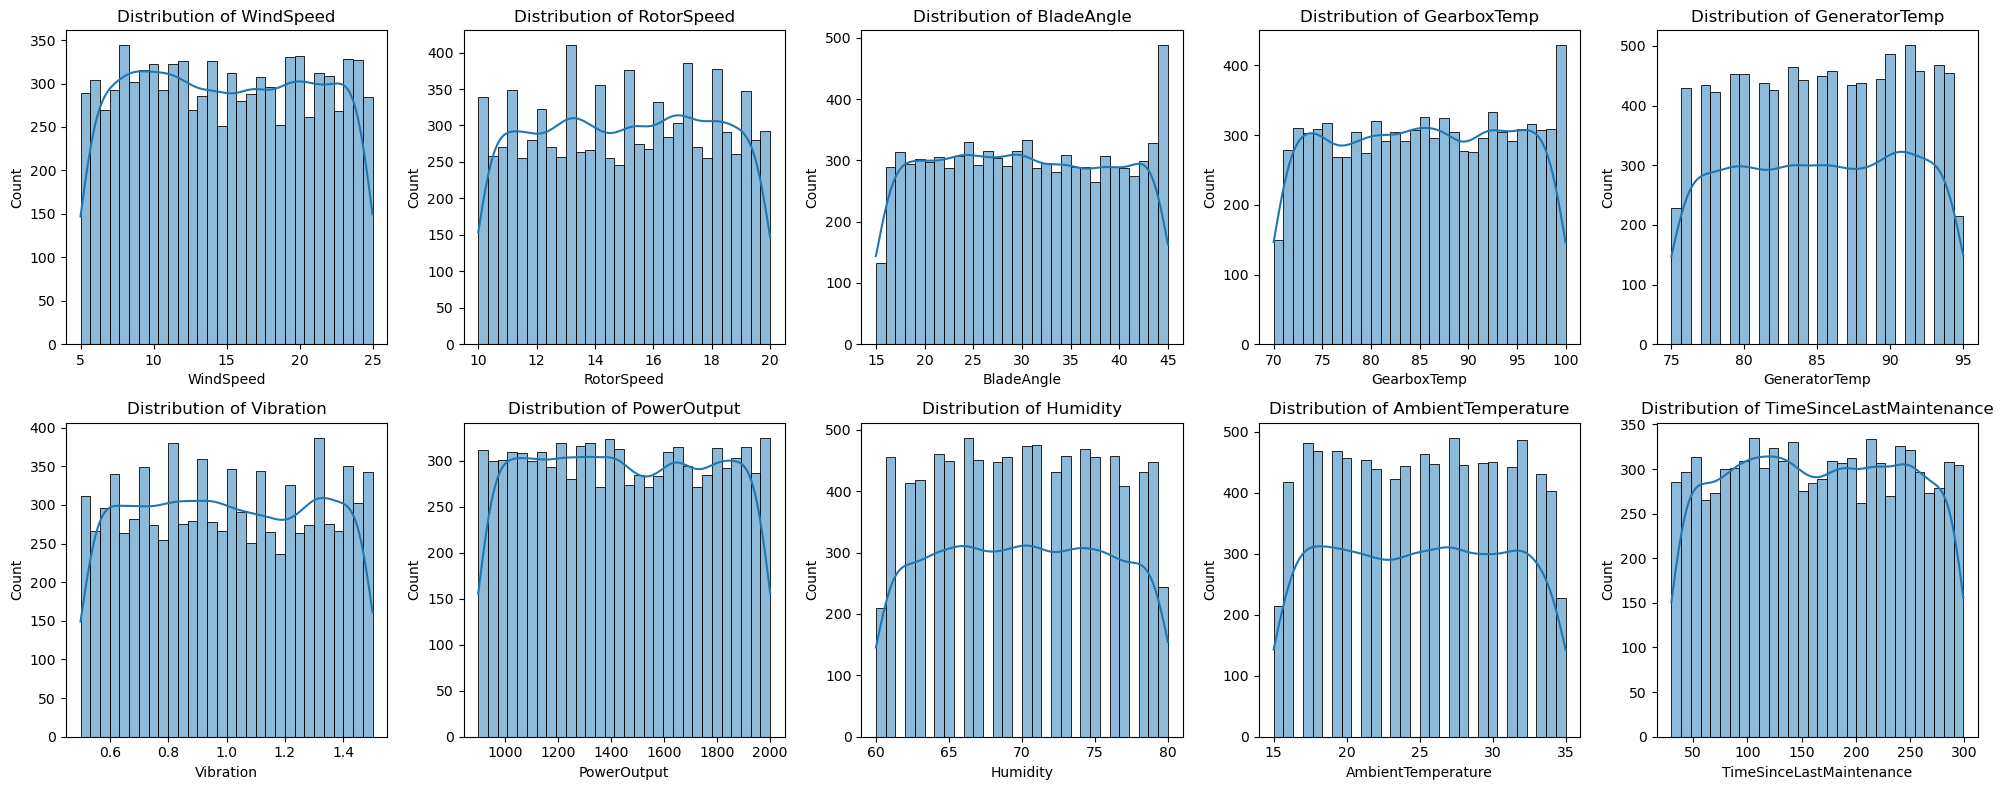

In [12]:
num_cols = ['WindSpeed','RotorSpeed','BladeAngle','GearboxTemp','GeneratorTemp','Vibration','PowerOutput','Humidity','AmbientTemperature','TimeSinceLastMaintenance']
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


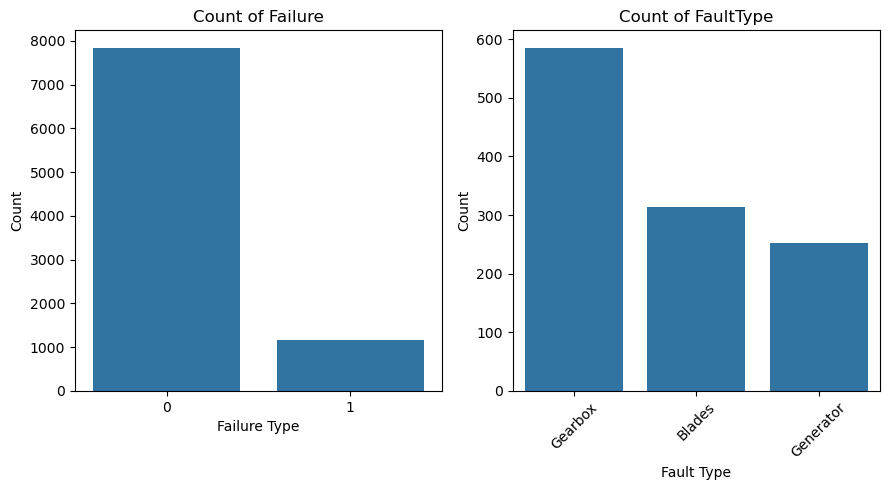

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5))  

#failure counts
sns.countplot(x="Failure", data=df, ax=axes[0], order=df["Failure"].value_counts().index)
axes[0].set_title("Count of Failure")
axes[0].set_xlabel("Failure Type")
axes[0].set_ylabel("Count")

#fault type counts
sns.countplot(x="FaultType", data=df, ax=axes[1], order=df["FaultType"].value_counts().index)
axes[1].set_title("Count of FaultType")
axes[1].set_xlabel("Fault Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

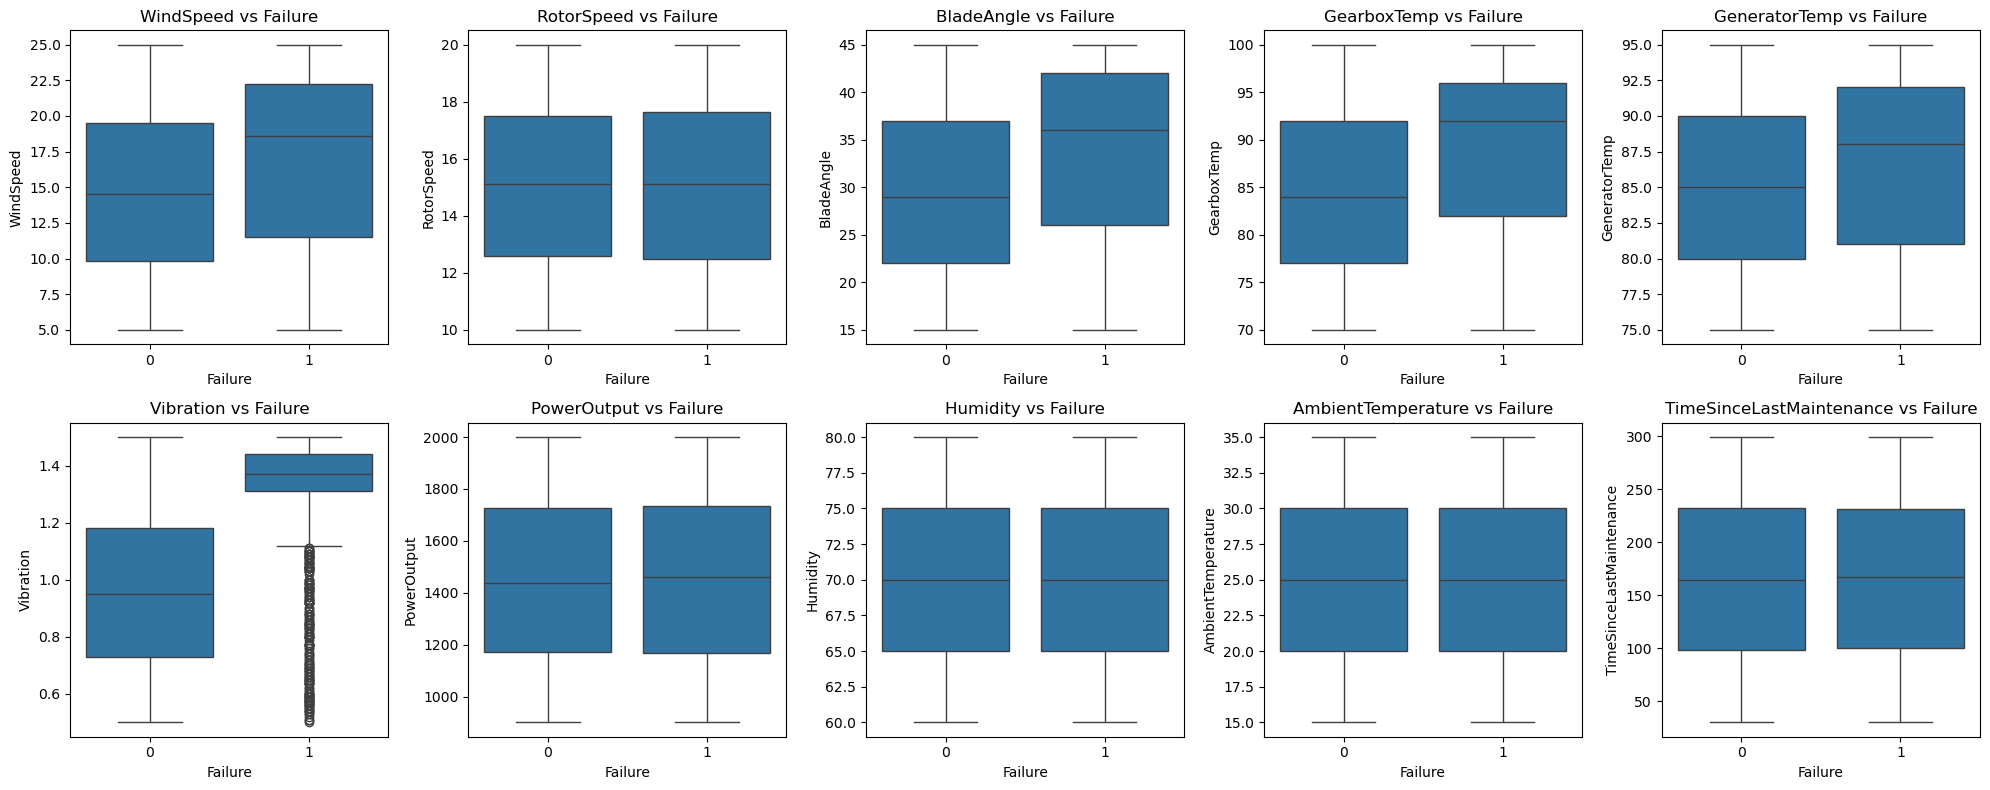

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()  
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="Failure", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Failure")

plt.tight_layout()
plt.show()

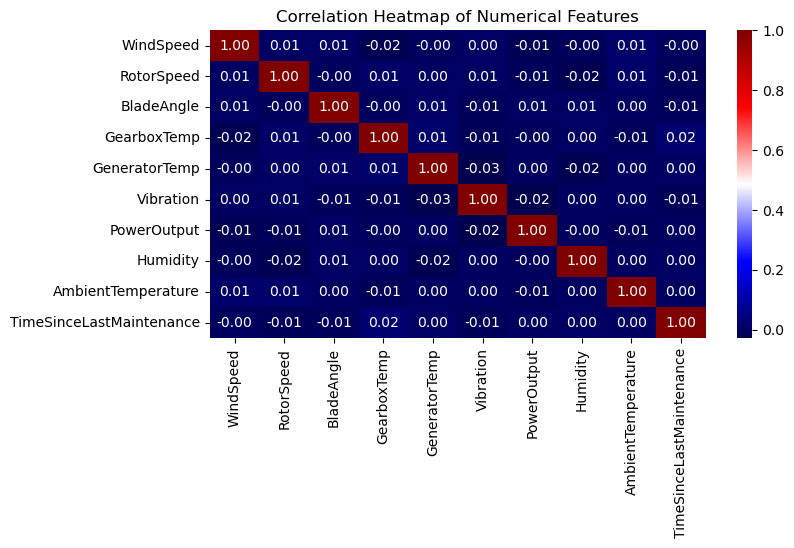

In [15]:
plt.figure(figsize=(8,4))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="seismic", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [16]:
df.describe()

,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,14.972944,15.014489,30.020556,85.066222,85.121000,1.001574,1447.854556,70.033556,24.961667,164.715444,0.128000
std,5.786175,2.882054,8.685036,8.653435,5.783124,0.290811,319.898071,5.742907,5.756860,77.479453,0.334108
min,5.000000,10.000000,15.000000,70.000000,75.000000,0.500000,900.000000,60.000000,15.000000,30.000000,0.000000
25%,9.900000,12.500000,23.000000,78.000000,80.000000,0.750000,1171.000000,65.000000,20.000000,98.750000,0.000000
50%,14.900000,15.100000,30.000000,85.000000,85.000000,1.000000,1441.000000,70.000000,25.000000,164.000000,0.000000
75%,20.000000,17.500000,38.000000,93.000000,90.000000,1.260000,1728.000000,75.000000,30.000000,232.000000,0.000000
max,25.000000,20.000000,45.000000,100.000000,95.000000,1.500000,2000.000000,80.000000,35.000000,299.000000,1.000000


In [17]:
df['FaultType'].value_counts()

FaultType
Gearbox      586
Blades       314
Generator    252
Name: count, dtype: int64

In [18]:
df['FaultType'].unique()

array([nan, 'Generator', 'Blades', 'Gearbox'], dtype=object)

In [19]:
df.fillna("No Error",inplace=True)

In [20]:
df['FaultType'].value_counts()

FaultType
No Error     7848
Gearbox       586
Blades        314
Generator     252
Name: count, dtype: int64

In [21]:
#binary classification
df_binary = df.drop(['TurbineID', 'FaultType'], axis=1)
#multi class classification
df_mul= df[(df['Failure'] == 1) & (df['FaultType'])]
df_mul

,TurbineID,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,FaultType
4,T16,8.6,13.8,27,79,93,1.33,1485,79,21,180,1,Generator
31,T59,24.3,19.5,44,72,80,0.58,1698,67,17,142,1,Blades
32,T69,10.6,13.4,29,93,77,1.46,1025,72,27,196,1,Gearbox
49,T77,12.5,12.0,16,97,89,1.44,934,74,19,91,1,Gearbox
52,T71,24.1,12.4,38,74,93,1.31,1522,62,18,148,1,Generator
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8965,T64,23.9,16.7,41,76,79,0.97,1792,65,16,291,1,Blades
8970,T82,23.0,10.5,44,72,75,0.84,1151,65,24,140,1,Blades
8977,T2,15.8,12.7,43,97,78,1.33,1921,69,34,154,1,Gearbox
8982,T35,19.7,16.6,40,72,94,1.36,1133,63,30,184,1,Generator


In [22]:
from sklearn.model_selection import train_test_split

# Define features and label
X = df_binary.drop('Failure', axis=1)
y = df_binary['Failure']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

Model Performance Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1575
           1       1.00      1.00      1.00       225

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



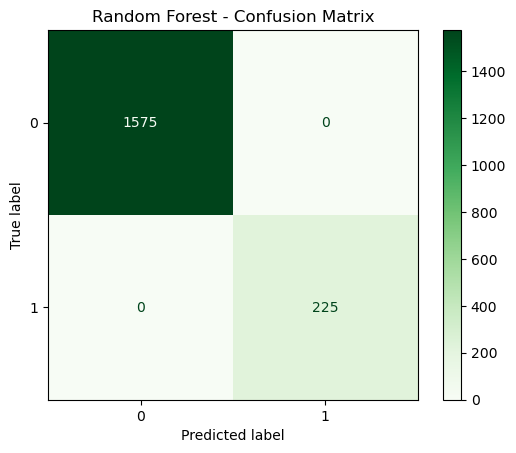

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Make predictions
y_pred = rf_model.predict(X_test)

#  classification results
print("Model Performance Report:\n")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap="Greens")
plt.title("Random Forest - Confusion Matrix")
plt.show()

**1. RANDOM FOREST** 

- TN (True Negatives): 1575
- TP (True Positives): 225
- FP (False Positives): 0
- FN (False Negatives): 0
- Perfect classification (100% accuracy, precision, recall, F1-score).

In [25]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

                    Feature  Importance
5                 Vibration    0.469444
2                BladeAngle    0.165122
0                 WindSpeed    0.122530
3               GearboxTemp    0.115195
4             GeneratorTemp    0.085338
6               PowerOutput    0.010335
9  TimeSinceLastMaintenance    0.009371
1                RotorSpeed    0.008713
8        AmbientTemperature    0.007023
7                  Humidity    0.006930


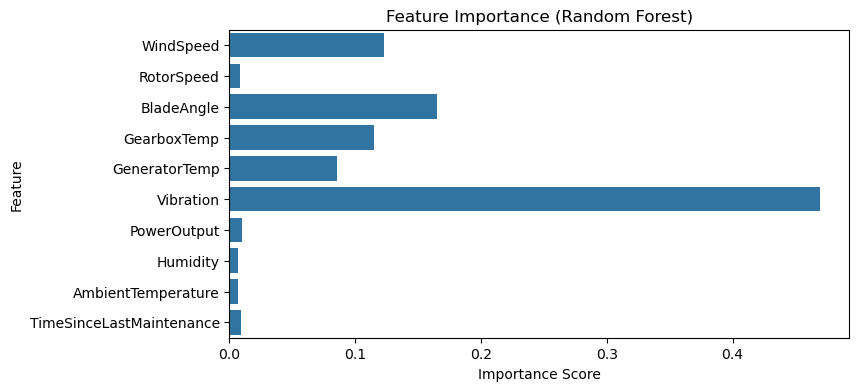

In [26]:
importances = rf_model.feature_importances_
features = X.columns

# plot
plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [27]:
from sklearn.tree import DecisionTreeClassifier
clf_gini = DecisionTreeClassifier(criterion = 'gini' , max_depth = 3 , random_state = 0)
clf_gini.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [28]:
y_pred_gini = clf_gini.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score
print('Model accracy score with criterion gini index : {0:0.4f}'.format(accuracy_score(y_test,y_pred_gini)))

Model accracy score with criterion gini index : 0.9911


[Text(0.5, 0.875, 'x[5] <= 1.305\ngini = 0.224\nsamples = 7200\nvalue = [6273, 927]'),
 Text(0.2, 0.625, 'x[2] <= 40.5\ngini = 0.071\nsamples = 5712\nvalue = [5503, 209]'),
 Text(0.35, 0.75, 'True  '),
 Text(0.1, 0.375, 'gini = 0.0\nsamples = 4814\nvalue = [4814, 0]'),
 Text(0.3, 0.375, 'x[0] <= 20.05\ngini = 0.357\nsamples = 898\nvalue = [689, 209]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 689\nvalue = [689, 0]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 209\nvalue = [0, 209]'),
 Text(0.8, 0.625, 'x[3] <= 90.5\ngini = 0.499\nsamples = 1488\nvalue = [770, 718]'),
 Text(0.65, 0.75, '  False'),
 Text(0.7, 0.375, 'x[4] <= 90.5\ngini = 0.362\nsamples = 1009\nvalue = [770, 239]'),
 Text(0.6, 0.125, 'gini = 0.085\nsamples = 806\nvalue = [770, 36]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 203\nvalue = [0, 203]'),
 Text(0.9, 0.375, 'gini = 0.0\nsamples = 479\nvalue = [0, 479]')]

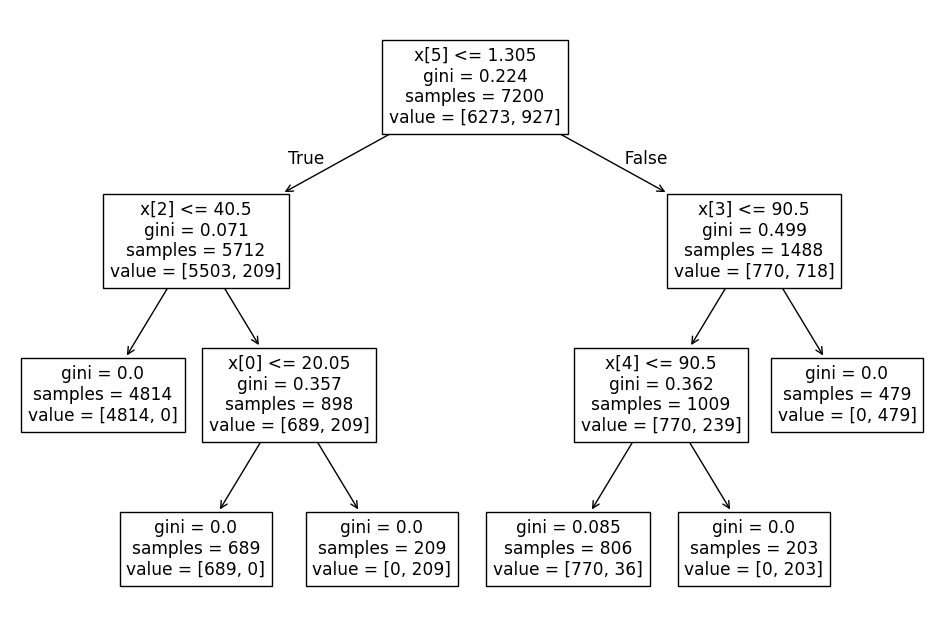

In [30]:
# Visualizing the decision tree
plt.figure(figsize = (12,8))
from sklearn import tree
tree.plot_tree(clf_gini.fit(X_train,y_train))

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
clf_gini.fit(X_train, y_train)
# Predictions
y_pred_gini = clf_gini.predict(X_test)
print("Model Performance Report:\n")
print(classification_report(y_test, y_pred_gini))  



Model Performance Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1575
           1       1.00      0.93      0.96       225

    accuracy                           0.99      1800
   macro avg       0.99      0.96      0.98      1800
weighted avg       0.99      0.99      0.99      1800



**2. DECISION TREE (Gini Index)**

- TN: 1575
- TP: 209
- FP: 0
- FN: 16
- Accuracy drops slightly because 16 positive cases were misclassified as negative.
- Precision = 100%, Recall ≈ 92.9%, F1-score slightly lower.

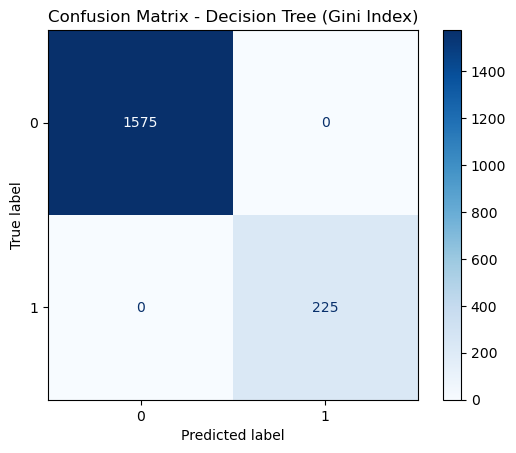

In [32]:
# Plot confusion matrix 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_gini.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree (Gini Index)")
plt.show()

In [33]:
df.columns

Index(['TurbineID', 'WindSpeed', 'RotorSpeed', 'BladeAngle', 'GearboxTemp',
       'GeneratorTemp', 'Vibration', 'PowerOutput', 'Humidity',
       'AmbientTemperature', 'TimeSinceLastMaintenance', 'Failure',
       'FaultType'],
      dtype='object')

In [34]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [35]:
# Importing libraries
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Creating and training the XGBoost model
model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [36]:
# predictions on the test data
y_pred_XG = model.predict(X_test)

# classification performance
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_XG))



XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1575
           1       1.00      1.00      1.00       225

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



**3. XGBOOST**
- TN: 1574
- TP: 225
- FP: 1
- FN: 0
- Accuracy is almost perfect. Just 1 false positive.
- Precision slightly less than Random Forest, Recall = 100%.

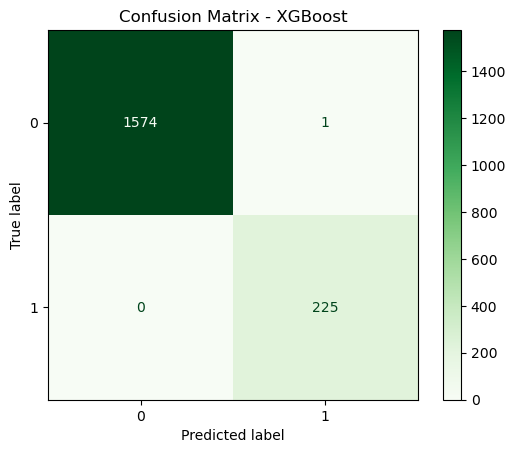

In [37]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_XG)
ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot(cmap='Greens')
plt.title("Confusion Matrix - XGBoost")
plt.show()

***FROM ABOVE 3 MODELS WE CAN UNDERSTAND THAT***

**1. RANDOM FOREST** 

- TN (True Negatives): 1575

- TP (True Positives): 225

- FP (False Positives): 0

- FN (False Negatives): 0

- Perfect classification (100% accuracy, precision, recall, F1-score).

**2. DECISION TREE (Gini Index)**

- TN: 1575

- TP: 209

- FP: 0

- FN: 16

- Accuracy drops slightly because 16 positive cases were misclassified as negative.

- Precision = 100%, Recall ≈ 92.9%, F1-score slightly lower.

**3. XGBOOST**

- TN: 1574

- TP: 225

- FP: 1

- FN: 0

- Accuracy is almost perfect. Just 1 false positive.

- Precision slightly less than Random Forest, Recall = 100%.

In [38]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

rf = RandomForestClassifier()
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, 
                                   n_iter=20, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
best_rf = random_search.best_estimator_

Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}


In [39]:
import pickle
pickle.dump(rf_model, open("RF_turbine_model.pkl", "wb")) 
print(" Model trained and saved as RF_turbine_model.pkl")

 Model trained and saved as RF_turbine_model.pkl


***visualizations***

In [40]:
import numpy as np

np.random.seed(42)
df['FailureProbability'] = df['Failure'] * 0.7 + np.random.rand(len(df)) * 0.3

# Health Score
df['HealthScore'] = (1 - df['FailureProbability']) * 100

# Risk Category
def categorize(p):
    if p < 0.3:
        return "Safe"
    elif p < 0.7:
        return "Warning"
    else:
        return "Risky"

df['RiskCategory'] = df['FailureProbability'].apply(categorize)

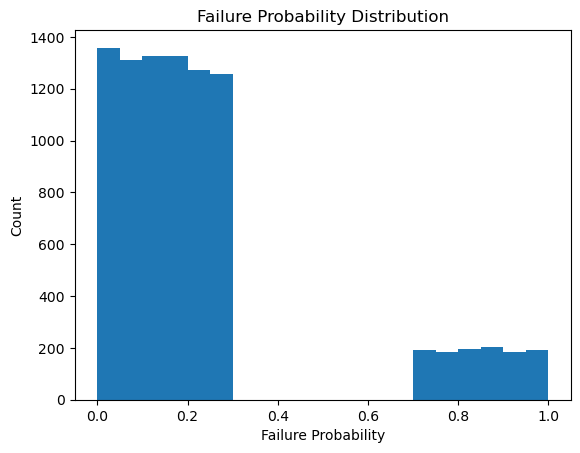

In [41]:
plt.figure()
plt.hist(df['FailureProbability'], bins=20)
plt.title("Failure Probability Distribution")
plt.xlabel("Failure Probability")
plt.ylabel("Count")
plt.show()

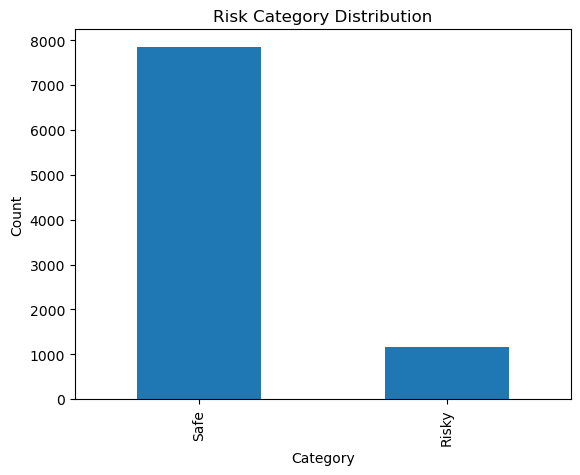

In [42]:
plt.figure()
df['RiskCategory'].value_counts().plot(kind='bar')
plt.title("Risk Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


In [44]:
alerts = df[df['FailureProbability'] > 0.7][['TurbineID','FailureProbability','RiskCategory']].head()
alerts

,TurbineID,FailureProbability,RiskCategory
4,T16,0.746806,Risky
31,T59,0.751157,Risky
32,T69,0.719515,Risky
49,T77,0.755456,Risky
52,T71,0.981850,Risky


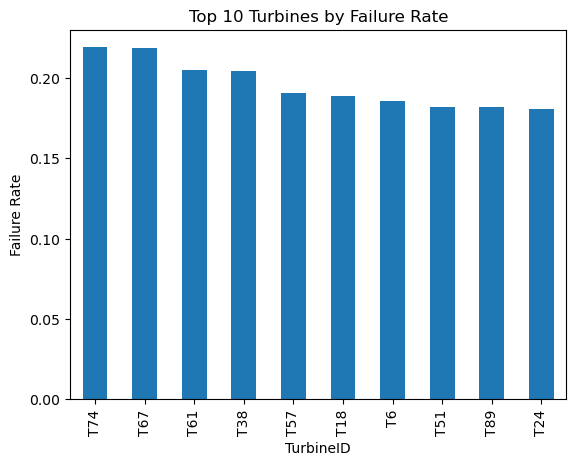

In [45]:
failure_rate = df.groupby('TurbineID')['Failure'].mean().sort_values(ascending=False).head(10)

plt.figure()
failure_rate.plot(kind='bar')
plt.title("Top 10 Turbines by Failure Rate")
plt.xlabel("TurbineID")
plt.ylabel("Failure Rate")
plt.show()

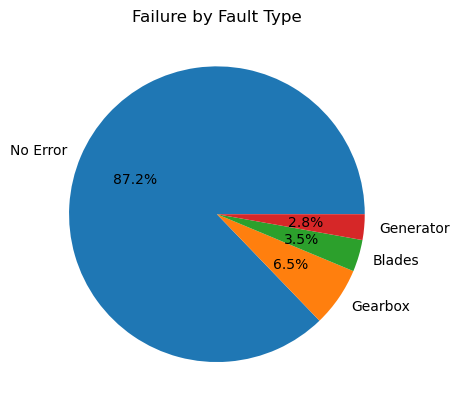

In [48]:
fault_counts = df['FaultType'].value_counts()

plt.figure()
fault_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Failure by Fault Type")
plt.ylabel("")
plt.show()